# API + Python in Jupyter: Weather Data Visualization Demo

## Goal
Learn how to:
1. Call a real API from Python
2. Read JSON data returned by the API
3. Convert the JSON into a pandas DataFrame
4. Visualize the results with matplotlib

## What we will do
We will use the Open-Meteo API to:
- Look up a city (geocoding endpoint)
- Request hourly weather data for that location (forecast endpoint)
- Plot temperature and precipitation over time

## Why this is useful
This is the same workflow used in many machine learning and data science projects:
- fetch data
- clean/reshape data
- inspect it
- visualize it

In [1]:
# Step 1: Import the libraries we need
# - requests: make HTTP/API calls
# - pandas: table/dataframe handling
# - matplotlib: plotting/visualization

import requests
import pandas as pd
import matplotlib.pyplot as plt

# Make plots a little easier to read in notebooks
plt.rcParams["figure.figsize"] = (12, 5)

# A tiny helper function so our API calls are clean and reusable
def get_json(url, params=None):
    """
    Send a GET request to an API endpoint and return the JSON response.
    
    Why this helper exists:
    - keeps our code short
    - gives us one place to handle request errors
    """
    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()  # raises an error if the request failed (4xx/5xx)
    return response.json()

## Step 2: Use a geocoding API to find latitude/longitude

Most weather APIs need coordinates (latitude/longitude), not just a city name.

So we first call a geocoding endpoint:
- input: a city name (for example, "Weatherford")
- output: matching places with coordinates

In [2]:
# Step 2: Geocoding API call (city name -> coordinates)

GEOCODE_URL = "https://geocoding-api.open-meteo.com/v1/search"

city_query = "Weatherford"

geocode_params = {
    "name": city_query,
    "count": 5,
    "language": "en"
}

geocode_data = get_json(GEOCODE_URL, geocode_params)

print("Full response keys:", geocode_data.keys())

results = geocode_data.get("results", [])

if not results:
    raise ValueError(f"No geocoding results found for: {city_query}")

# Convert to DataFrame for inspection
locations_df = pd.DataFrame(results)

# Filter for Weatherford, Oklahoma, Custer County
ok_weatherford = locations_df[
    (locations_df["admin1"] == "Oklahoma") &
    (locations_df["admin2"] == "Custer")
]

if ok_weatherford.empty:
    raise ValueError("Could not find Weatherford, Oklahoma in results.")

# Select the first matching row
chosen_location = ok_weatherford.iloc[0]

latitude = chosen_location["latitude"]
longitude = chosen_location["longitude"]
timezone = chosen_location["timezone"]

print(f"Selected location: {chosen_location['name']}, "
      f"{chosen_location['admin1']} ({chosen_location['admin2']})")
print(f"Latitude: {latitude}, Longitude: {longitude}")

locations_df

Full response keys: dict_keys(['results', 'generationtime_ms'])
Selected location: Weatherford, Oklahoma (Custer)
Latitude: 35.52616, Longitude: -98.70757


,id,name,latitude,longitude,elevation,feature_code,country_code,admin1_id,admin2_id,timezone,population,postcodes,country_id,country,admin1,admin2
0,4740364,Weatherford,32.75930,-97.79725,321.0,PPLA2,US,4736286,4717644,America/Chicago,28742.0,"[76085, 76086, 76087, 76088]",6252001,United States,Texas,Parker
1,4554858,Weatherford,35.52616,-98.70757,504.0,PPL,US,4544379,4534674,America/Chicago,12126.0,[73096],6252001,United States,Oklahoma,Custer
2,4229822,Weatherford,34.26732,-83.91740,360.0,PPL,US,4197000,4198821,America/New_York,NaN,NaN,6252001,United States,Georgia,Hall
3,4312844,Weatherford Knob,37.43063,-84.99968,329.0,MT,US,6254925,4287126,America/New_York,NaN,NaN,6252001,United States,Kentucky,Casey
4,4450464,Weatherford Lake Dam,34.39843,-88.24504,154.0,DAM,US,4436296,4431274,America/Chicago,NaN,NaN,6252001,United States,Mississippi,Itawamba


## Step 3: Choose a location and request hourly forecast data

Now that we have coordinates, we call the weather forecast endpoint.

We will request hourly values for:
- temperature_2m
- precipitation
- relative_humidity_2m

In [3]:
# Step 3: Pick the first matching location (you can choose another row if needed)
chosen = results[1]

city_name = chosen["name"]
country = chosen.get("country", "")
admin1 = chosen.get("admin1", "")
latitude = chosen["latitude"]
longitude = chosen["longitude"]
timezone = chosen.get("timezone", "auto")

print(f"Using location: {city_name}, {admin1}, {country}")
print(f"Latitude: {latitude}, Longitude: {longitude}, Timezone: {timezone}")

FORECAST_URL = "https://api.open-meteo.com/v1/forecast"

forecast_params = {
    "latitude": latitude,
    "longitude": longitude,
    "hourly": "temperature_2m,precipitation,relative_humidity_2m",
    "forecast_days": 5,
    "timezone": "auto"
}

forecast_data = get_json(FORECAST_URL, forecast_params)

# Quick peek at the response structure
print("Forecast keys:", forecast_data.keys())
print("Hourly keys:", forecast_data["hourly"].keys())

Using location: Weatherford, Oklahoma, United States
Latitude: 35.52616, Longitude: -98.70757, Timezone: America/Chicago
Forecast keys: dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])
Hourly keys: dict_keys(['time', 'temperature_2m', 'precipitation', 'relative_humidity_2m'])


## Step 4: Convert JSON into a pandas DataFrame

APIs often return nested JSON.
For analysis and plotting, we usually reshape it into a table.

This is a key data-science move:
JSON -> DataFrame -> analysis/visualization

In [10]:
# Step 4: Build a DataFrame from the hourly data block

hourly = forecast_data["hourly"]

weather_df = pd.DataFrame({
    "time": hourly["time"],
    "temperature_2m": hourly["temperature_2m"],
    "precipitation": hourly["precipitation"],
    "relative_humidity_2m": hourly["relative_humidity_2m"]
})

# Convert time strings to actual datetime objects
weather_df["time"] = pd.to_datetime(weather_df["time"])

# Set time as the index
weather_df = weather_df.set_index("time")

# 🔥 Tell pandas this is hourly time-series data
weather_df = weather_df.asfreq("h")

# Inspect the first few rows
weather_df.head()

,temperature_2m,precipitation,relative_humidity_2m
time,,,
2026-02-25 00:00:00,14.2,0.0,36
2026-02-25 01:00:00,10.7,0.0,45
2026-02-25 02:00:00,8.0,0.0,58
2026-02-25 03:00:00,6.2,0.0,62
2026-02-25 04:00:00,5.2,0.0,65


## Step 5: Do a couple of simple analyses

Before plotting, let's compute a daily summary.
This shows how the same API data can support multiple kinds of analysis.

In [11]:
# Step 5: Daily summary from hourly data
daily_summary = weather_df.resample("D").agg({
    "temperature_2m": ["min", "max", "mean"],
    "precipitation": "sum",
    "relative_humidity_2m": "mean"
})

daily_summary

temperature_2m                  precipitation relative_humidity_2m
                      min   max       mean           sum                 mean
time                                                                         
2026-02-25            3.9  24.1  13.870833           0.0            43.250000
2026-02-26            9.3  22.8  15.633333           0.0            33.250000
2026-02-27           10.1  24.0  16.170833           0.0            35.041667
2026-02-28           11.5  26.7  18.433333           1.7            53.375000
2026-03-01            2.0  25.6  14.087500           0.2            88.000000

## Step 6: Visualize the results

We will make two plots:
1. Hourly temperature over time
2. Hourly precipitation over time (bar chart)

This is the "see the shape of the data" moment.

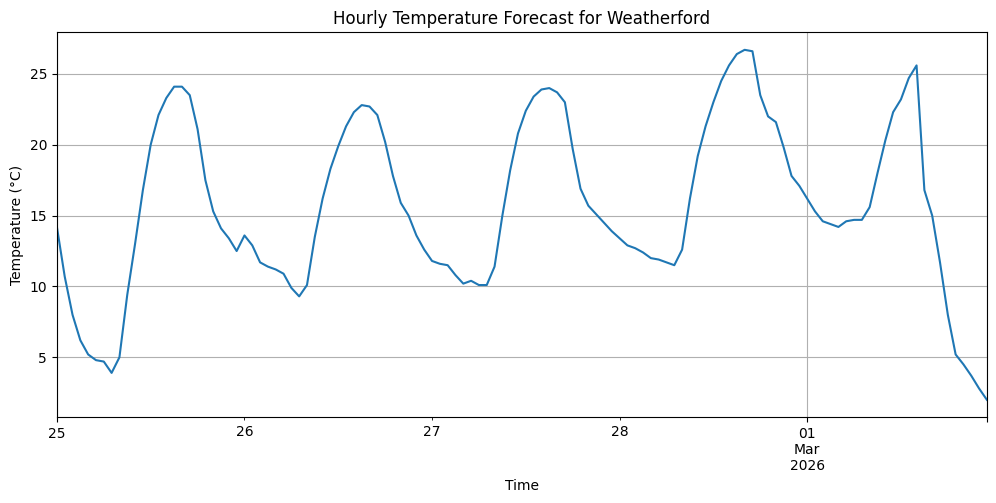

In [12]:
# Step 6A: Plot hourly temperature
plt.figure()
weather_df["temperature_2m"].plot()
plt.title(f"Hourly Temperature Forecast for {city_name}")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

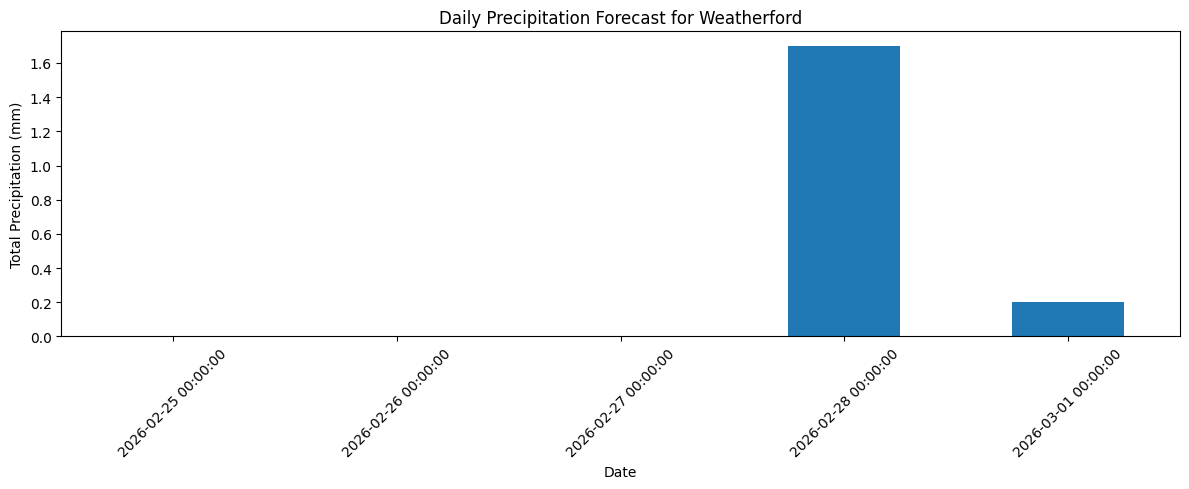

In [14]:
# Step 6B: Plot daily precipitation totals (cleaner visualization)

daily_precip = weather_df["precipitation"].resample("D").sum()

plt.figure()
daily_precip.plot(kind="bar")
plt.title(f"Daily Precipitation Forecast for {city_name}")
plt.xlabel("Date")
plt.ylabel("Total Precipitation (mm)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Why we did the key steps

### 1) Geocoding first
Weather APIs often require coordinates, so we used a geocoding endpoint to translate a city name into latitude/longitude.

### 2) Parameterized API calls
We passed parameters like `hourly`, `forecast_days`, and `timezone`.
This makes the request reproducible and easy to change.

### 3) JSON to DataFrame
API responses are usually JSON, but plotting and analysis are easier in pandas.
Converting to a DataFrame is a standard workflow in data science and ML preprocessing.

### 4) Datetime conversion
Turning timestamps into real datetime values lets us:
- resample by day
- sort naturally
- create better time-series plots

### 5) Visualization
Plots help us quickly inspect trends, spikes, and possible data issues before doing any modeling.

## Next ideas (great practice)
- Compare two cities on the same chart
- Request more variables (wind speed, cloud cover, apparent temperature)
- Save the DataFrame to CSV
- Build a tiny model using the weather data later

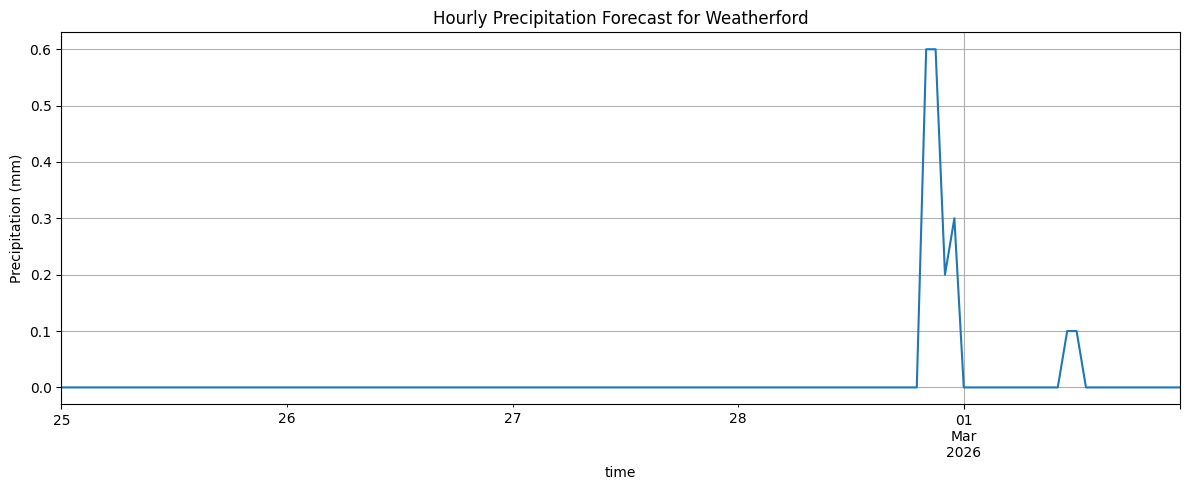

In [16]:
plt.figure()
weather_df["precipitation"].plot()
plt.title(f"Hourly Precipitation Forecast for {city_name}")
plt.ylabel("Precipitation (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()